In [5]:
!pip install kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 322.7 kB/s eta 0:00:001m364.1 kB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 1.3 MB/s eta 0:00:00 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.8/217.8 kB 1.4 MB/s eta 0:00:003 kB/s eta 0:00:0101
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.14
    Uninstalling kagglesdk-0.1.14:
      Successfully uninstalled kagglesdk-0.1.14


In [47]:
# Import required libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import torchvision
from torchvision import datasets, models

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import kagglehub

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [71]:
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as transforms
import os

class SuperResolutionDataset(Dataset):

    def __init__(self, lr_dir, hr_dir):

        self.lr_dir = lr_dir
        self.hr_dir = hr_dir

        VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}
        self.lr_images = sorted([f for f in os.listdir(lr_dir)
                                  if os.path.splitext(f)[1].lower() in VALID_EXTS])
        self.hr_images = sorted([f for f in os.listdir(hr_dir)
                                  if os.path.splitext(f)[1].lower() in VALID_EXTS])

        self.transform = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
         ])

    def __len__(self):
        return len(self.lr_images)

    def __getitem__(self, idx):

        lr_path = os.path.join(self.lr_dir, self.lr_images[idx])
        hr_path = os.path.join(self.hr_dir, self.hr_images[idx])

        lr_image = Image.open(lr_path).convert("RGB")
        hr_image = Image.open(hr_path).convert("RGB")

        lr_image = self.transform(lr_image)
        hr_image = self.transform(hr_image)

        return lr_image, hr_image

In [73]:
path = kagglehub.dataset_download("adityachandrasekhar/image-super-resolution")

lr_path = os.path.join(path, 'dataset', 'train', 'low_res')
hr_path = os.path.join(path, 'dataset', 'train', 'high_res')

from torchvision import transforms as T

lr_transform = T.Compose([T.Resize((64, 64)), T.ToTensor(), T.Normalize([0.5]*3, [0.5]*3)])
hr_transform = T.Compose([T.Resize((256, 256)), T.ToTensor(), T.Normalize([0.5]*3, [0.5]*3)])

class SRDataset4x(SuperResolutionDataset):
    def __getitem__(self, idx):
        lr = Image.open(os.path.join(self.lr_dir, self.lr_images[idx])).convert("RGB")
        hr = Image.open(os.path.join(self.hr_dir, self.hr_images[idx])).convert("RGB")
        return lr_transform(lr), hr_transform(hr)

sr_dataset = SRDataset4x(lr_path, hr_path)

print("Total image pairs:", len(sr_dataset))

sr_loader = DataLoader(
    sr_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

Total image pairs: 685


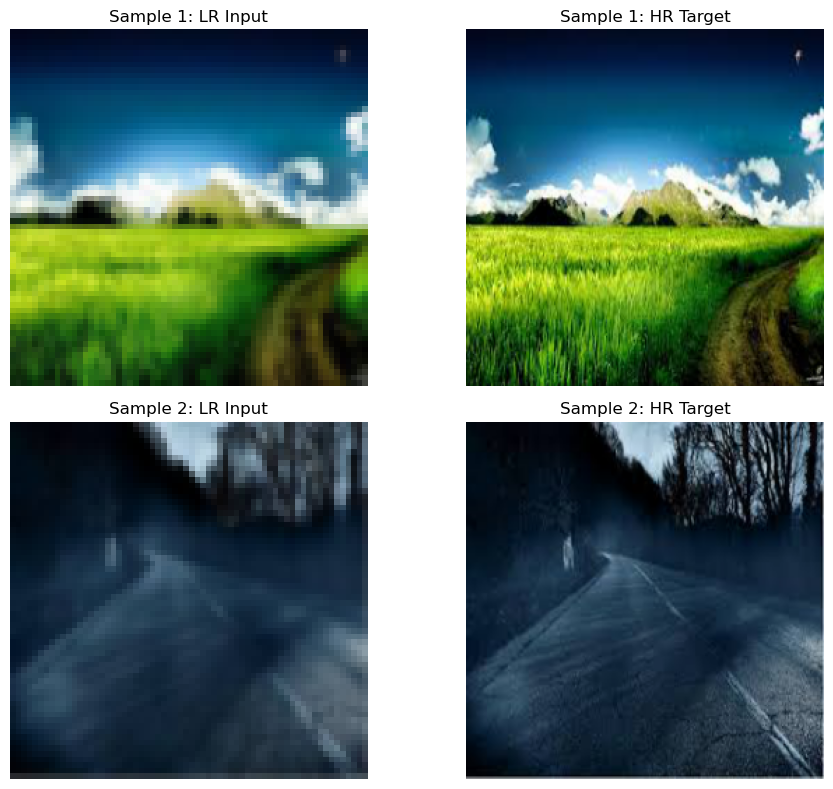

In [75]:
# Visualize a few samples
def preview_dataset_samples(dataloader, num_samples=4):
    lr_batch, hr_batch = next(iter(dataloader))
    num_samples = min(num_samples, lr_batch.size(0))
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))
    if num_samples == 1:
        axes = [axes]

    for i in range(num_samples):
        lr_img = (lr_batch[i].cpu() * 0.5 + 0.5).clamp(0, 1)
        hr_img = (hr_batch[i].cpu() * 0.5 + 0.5).clamp(0, 1)
        lr_img = transforms.ToPILImage()(lr_img)
        hr_img = transforms.ToPILImage()(hr_img)
        axes[i][0].imshow(lr_img)
        axes[i][0].set_title(f"Sample {i+1}: LR Input")
        axes[i][0].axis('off')
        axes[i][1].imshow(hr_img)
        axes[i][1].set_title(f"Sample {i+1}: HR Target")
        axes[i][1].axis('off')
    plt.tight_layout()
    plt.show()

preview_dataset_samples(sr_loader)

In [77]:
class BasicGenerator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, base_filters=64):
        super(BasicGenerator, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, base_filters, 3, 1, 1),
            nn.ReLU(True),
            nn.Conv2d(base_filters, base_filters, 3, 1, 1),
            nn.ReLU(True),
        )
        self.upsample = nn.Sequential(
            nn.Conv2d(base_filters, base_filters * 4, 3, 1, 1),
            nn.PixelShuffle(2),
            nn.ReLU(True),
            nn.Conv2d(base_filters, base_filters * 4, 3, 1, 1),
            nn.PixelShuffle(2),
            nn.ReLU(True),
        )
        self.output = nn.Sequential(
            nn.Conv2d(base_filters, base_filters, 3, 1, 1),
            nn.ReLU(True),
            nn.Conv2d(base_filters, out_channels, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.upsample(x)
        return self.output(x)

class BasicDiscriminator(nn.Module):
    def __init__(self, in_channels=3, base_filters=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels, base_filters, 3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_filters, base_filters, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_filters, base_filters * 2, 3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_filters * 2, base_filters * 2, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_filters * 2, base_filters * 4, 3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_filters * 4, base_filters * 4, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(base_filters * 4, 1)
        )
    def forward(self, x):
        return self.model(x)

print("Basic GAN components defined successfully!")

Basic GAN components defined successfully!


In [79]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.prelu = nn.PReLU()
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.prelu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = out + residual
        return out

class SRGANGenerator(nn.Module):
    def __init__(self, in_channels=3, num_residual_blocks=16, base_filters=64, scale_factor=2):
        super(SRGANGenerator, self).__init__()
        self.scale_factor = scale_factor
        self.conv1 = nn.Conv2d(in_channels, base_filters, kernel_size=9, padding=4)
        self.prelu1 = nn.PReLU()
        self.residual_blocks = nn.Sequential(
            *[ResidualBlock(base_filters) for _ in range(num_residual_blocks)]
        )
        self.conv2 = nn.Conv2d(base_filters, base_filters, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(base_filters)
        self.upsampling = nn.Sequential()
        if scale_factor == 2:
            self.upsampling.add_module('up1', nn.Conv2d(base_filters, base_filters * 4, kernel_size=3, padding=1))
            self.upsampling.add_module('pixel1', nn.PixelShuffle(2))
            self.upsampling.add_module('relu1', nn.PReLU())
        elif scale_factor == 4:
            self.upsampling.add_module('up1', nn.Conv2d(base_filters, base_filters * 4, kernel_size=3, padding=1))
            self.upsampling.add_module('pixel1', nn.PixelShuffle(2))
            self.upsampling.add_module('relu1', nn.PReLU())
            self.upsampling.add_module('up2', nn.Conv2d(base_filters, base_filters * 4, kernel_size=3, padding=1))
            self.upsampling.add_module('pixel2', nn.PixelShuffle(2))
            self.upsampling.add_module('relu2', nn.PReLU())
        self.conv3 = nn.Conv2d(base_filters, in_channels, kernel_size=9, padding=4)
        self.tanh = nn.Tanh()

    def forward(self, x):
        out = self.conv1(x)
        out = self.prelu1(out)
        residual = out
        out = self.residual_blocks(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = out + residual
        out = self.upsampling(out)
        out = self.conv3(out)
        out = self.tanh(out)
        return out

class SRGANDiscriminator(nn.Module):
    def __init__(self, in_channels=3, base_filters=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels, base_filters, 3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_filters, base_filters, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_filters, base_filters * 2, 3, padding=1),
            nn.BatchNorm2d(base_filters * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_filters * 2, base_filters * 2, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_filters * 2, base_filters * 4, 3, padding=1),
            nn.BatchNorm2d(base_filters * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_filters * 4, base_filters * 4, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_filters * 4, base_filters * 8, 3, padding=1),
            nn.BatchNorm2d(base_filters * 8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_filters * 8, base_filters * 8, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(base_filters * 8, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 1)
        )
    def forward(self, x):
        return self.model(x)

print("SRGAN components defined successfully!")

SRGAN components defined successfully!


In [81]:
class DenseBlock(nn.Module):
    def __init__(self, channels, growth_channels=32):
        super().__init__()
        self.lrelu = nn.LeakyReLU(0.2, inplace=True)
        self.conv1 = nn.Conv2d(channels, growth_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(channels + growth_channels, growth_channels, 3, padding=1)
        self.conv3 = nn.Conv2d(channels + 2*growth_channels, growth_channels, 3, padding=1)
        self.conv4 = nn.Conv2d(channels + 3*growth_channels, growth_channels, 3, padding=1)
        self.conv5 = nn.Conv2d(channels + 4*growth_channels, channels, 3, padding=1)
        self.beta = 0.2

    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.cat([x, x1], 1)))
        x3 = self.lrelu(self.conv3(torch.cat([x, x1, x2], 1)))
        x4 = self.lrelu(self.conv4(torch.cat([x, x1, x2, x3], 1)))
        x5 = self.conv5(torch.cat([x, x1, x2, x3, x4], 1))
        return x + x5 * self.beta

class RRDB(nn.Module):
    def __init__(self, channels, growth_channels=32):
        super().__init__()
        self.rdb1 = DenseBlock(channels, growth_channels)
        self.rdb2 = DenseBlock(channels, growth_channels)
        self.rdb3 = DenseBlock(channels, growth_channels)
        self.beta = 0.2

    def forward(self, x):
        out = self.rdb1(x)
        out = self.rdb2(out)
        out = self.rdb3(out)
        return x + out * self.beta

class ESRGANGenerator(nn.Module):
    def __init__(self, in_channels=3, num_rrdb_blocks=23, base_filters=64, growth_channels=32, scale_factor=4):
        super().__init__()
        self.scale_factor = scale_factor
        self.conv_first = nn.Conv2d(in_channels, base_filters, 3, padding=1)
        self.trunk = nn.Sequential(*[RRDB(base_filters, growth_channels) for _ in range(num_rrdb_blocks)])
        self.trunk_conv = nn.Conv2d(base_filters, base_filters, 3, padding=1)
        up_layers = []
        for i in range(int(np.log2(scale_factor))):
            up_layers += [
                nn.Conv2d(base_filters, base_filters * 4, 3, padding=1),
                nn.PixelShuffle(2),
                nn.LeakyReLU(0.2, inplace=True)
            ]
        self.upsampler = nn.Sequential(*up_layers)
        self.conv_last = nn.Sequential(
            nn.Conv2d(base_filters, base_filters, 3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_filters, in_channels, 3, padding=1)
        )

    def forward(self, x):
        fea = self.conv_first(x)
        trunk = self.trunk(fea)
        trunk = self.trunk_conv(trunk)
        fea = fea + trunk
        out = self.upsampler(fea)
        out = self.conv_last(out)
        return torch.tanh(out)

class ESRGANDiscriminator(nn.Module):
    def __init__(self, in_channels=3, base_filters=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels, base_filters, 3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_filters, base_filters, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_filters, base_filters * 2, 3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_filters * 2, base_filters * 2, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_filters * 2, base_filters * 4, 3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_filters * 4, base_filters * 4, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_filters * 4, base_filters * 8, 3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_filters * 8, base_filters * 8, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(base_filters * 8, 1)
        )
    def forward(self, x):
        return self.model(x)

print("ESRGAN components defined successfully!")

ESRGAN components defined successfully!


In [83]:
class PerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = torchvision.models.vgg19(weights=torchvision.models.VGG19_Weights.DEFAULT).features[:16].eval()
        for p in vgg.parameters():
            p.requires_grad = False
        self.vgg = vgg
        self.mse = nn.MSELoss()
        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1))
        self.register_buffer('std', torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1))

    def forward(self, sr, hr):
        sr = (sr + 1) / 2
        hr = (hr + 1) / 2
        sr = (sr - self.mean) / self.std
        hr = (hr - self.mean) / self.std
        sr_feat = self.vgg(sr)
        hr_feat = self.vgg(hr)
        return self.mse(sr_feat, hr_feat)

class ContentLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()
    def forward(self, sr, hr):
        return self.mse(sr, hr)

class AdversarialLoss(nn.Module):
    def __init__(self, loss_type='mse'):
        super().__init__()
        self.criterion = nn.BCEWithLogitsLoss() if loss_type == 'bce' else nn.MSELoss()
    def forward(self, preds, target_is_real=True):
        target = torch.ones_like(preds) if target_is_real else torch.zeros_like(preds)
        return self.criterion(preds, target)

print("Loss functions defined successfully!")

Loss functions defined successfully!


In [85]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tqdm import tqdm
import torchvision

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mse_loss = nn.MSELoss()

def compute_psnr(fake, real):
    fake = (fake + 1) / 2
    real = (real + 1) / 2
    mse = mse_loss(fake, real)
    return 10 * torch.log10(1.0 / mse.clamp(min=1e-10))

def pretrain_generator(generator, dataloader, epochs=5, device='cuda'):
    generator.to(device)
    generator.train()
    optimizer = torch.optim.Adam(generator.parameters(), lr=1e-4)
    criterion = nn.MSELoss()
    device_str = device.type if hasattr(device, 'type') else str(device)
    use_amp = ('cuda' in device_str)
    scaler = torch.cuda.amp.GradScaler() if use_amp else None

    for epoch in range(epochs):
        losses = []
        progress_bar = tqdm(dataloader, desc=f"Pretrain Epoch {epoch+1}/{epochs}", leave=True)
        for lr_imgs, hr_imgs in progress_bar:
            lr_imgs = lr_imgs.to(device, non_blocking=True)
            hr_imgs = hr_imgs.to(device, non_blocking=True)
            optimizer.zero_grad()
            if use_amp:
                with torch.cuda.amp.autocast():
                    fake_imgs = generator(lr_imgs)
                    # FIX: removed silent resize – now enforce correct shape
                    assert fake_imgs.shape == hr_imgs.shape, \
                        f"Shape mismatch: fake {fake_imgs.shape} vs hr {hr_imgs.shape}"
                    loss = criterion(fake_imgs, hr_imgs)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                fake_imgs = generator(lr_imgs)
                assert fake_imgs.shape == hr_imgs.shape, \
                    f"Shape mismatch: fake {fake_imgs.shape} vs hr {hr_imgs.shape}"
                loss = criterion(fake_imgs, hr_imgs)
                loss.backward()
                optimizer.step()
            losses.append(loss.item())
            progress_bar.set_postfix({"loss": f"{loss.item():.4f}"})
        print(f"Epoch {epoch+1}: Avg Loss = {np.mean(losses):.4f}")

In [87]:
# =========================
# BASIC GAN (with AMP)
# =========================
def train_basic_gan(generator, discriminator, dataloader, epochs,
                    lr_g=0.0002, lr_d=0.0002, device='cuda'):
    generator.to(device)
    discriminator.to(device)
    criterion = nn.BCEWithLogitsLoss()
    content_loss = ContentLoss().to(device)
    optimizer_g = optim.Adam(generator.parameters(), lr=lr_g, betas=(0.5, 0.999))
    optimizer_d = optim.Adam(discriminator.parameters(), lr=lr_d, betas=(0.5, 0.999))
    use_amp = (device == 'cuda')
    scaler_g = torch.cuda.amp.GradScaler() if use_amp else None
    scaler_d = torch.cuda.amp.GradScaler() if use_amp else None
    history = {'g_loss': [], 'd_loss': [], 'psnr': []}

    for epoch in range(epochs):
        g_losses, d_losses, psnrs = [], [], []
        generator.train()
        discriminator.train()
        loop = tqdm(dataloader, desc=f'GAN Epoch {epoch+1}/{epochs}')
        for lr_imgs, hr_imgs in loop:
            lr_imgs = lr_imgs.to(device, non_blocking=True)
            hr_imgs = hr_imgs.to(device, non_blocking=True)

            # Train Discriminator
            optimizer_d.zero_grad()
            if use_amp:
                with torch.cuda.amp.autocast():
                    real_output = discriminator(hr_imgs)
                    real_loss = criterion(real_output, torch.ones_like(real_output))
                    fake_imgs = generator(lr_imgs)
                    fake_output = discriminator(fake_imgs.detach())
                    fake_loss = criterion(fake_output, torch.zeros_like(fake_output))
                    d_loss = real_loss + fake_loss
                scaler_d.scale(d_loss).backward()
                scaler_d.step(optimizer_d)
                scaler_d.update()
            else:
                real_output = discriminator(hr_imgs)
                real_loss = criterion(real_output, torch.ones_like(real_output))
                fake_imgs = generator(lr_imgs)
                fake_output = discriminator(fake_imgs.detach())
                fake_loss = criterion(fake_output, torch.zeros_like(fake_output))
                d_loss = real_loss + fake_loss
                d_loss.backward()
                optimizer_d.step()

            # Train Generator
            optimizer_g.zero_grad()
            if use_amp:
                with torch.cuda.amp.autocast():
                    fake_imgs = generator(lr_imgs)
                    fake_output = discriminator(fake_imgs)
                    g_adv = criterion(fake_output, torch.ones_like(fake_output))
                    g_content = content_loss(fake_imgs, hr_imgs)
                    g_loss = g_content + 0.001 * g_adv
                scaler_g.scale(g_loss).backward()
                scaler_g.step(optimizer_g)
                scaler_g.update()
            else:
                fake_imgs = generator(lr_imgs)
                fake_output = discriminator(fake_imgs)
                g_adv = criterion(fake_output, torch.ones_like(fake_output))
                g_content = content_loss(fake_imgs, hr_imgs)
                g_loss = g_content + 0.001 * g_adv
                g_loss.backward()
                optimizer_g.step()

            # FIX: store PSNR for every batch
            with torch.no_grad():
                psnr = compute_psnr(fake_imgs, hr_imgs)
                psnrs.append(psnr.item())

            g_losses.append(g_loss.item())
            d_losses.append(d_loss.item())
            loop.set_postfix(G_loss=g_loss.item(), D_loss=d_loss.item())

        history['g_loss'].append(np.mean(g_losses))
        history['d_loss'].append(np.mean(d_losses))
        history['psnr'].append(np.mean(psnrs))
        print(f"Epoch {epoch+1}/{epochs} | G: {history['g_loss'][-1]:.4f} | "
              f"D: {history['d_loss'][-1]:.4f} | PSNR: {history['psnr'][-1]:.2f}")
    return history

# =========================
# SRGAN (optimized)
# =========================
def train_srgan(generator, discriminator, dataloader, epochs, device):
    # Force models to the correct device
    generator = generator.to(device)
    discriminator = discriminator.to(device)

    adversarial_loss = nn.BCEWithLogitsLoss().to(device)
    pixel_loss = nn.L1Loss().to(device)
    perceptual_loss_fn = PerceptualLoss().to(device)

    optimizer_G = optim.Adam(generator.parameters(), lr=1e-4, betas=(0.9, 0.999))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=1e-4, betas=(0.9, 0.999))

    # Disable AMP to avoid dtype errors
    use_amp = False

    history = {"g_loss": [], "d_loss": [], "psnr": []}

    for epoch in range(epochs):
        loop = tqdm(dataloader, desc=f"SRGAN Epoch [{epoch+1}/{epochs}]")
        g_loss_epoch, d_loss_epoch = 0, 0
        psnrs = []          # ← collect PSNR per batch

        for lr_imgs, hr_imgs in loop:
            lr_imgs = lr_imgs.to(device, non_blocking=True)
            hr_imgs = hr_imgs.to(device, non_blocking=True)
            batch_size = lr_imgs.size(0)
            real_labels = torch.ones((batch_size, 1), device=device)
            fake_labels = torch.zeros((batch_size, 1), device=device)

            # ---------------------
            #  Train Discriminator
            # ---------------------
            optimizer_D.zero_grad()
            fake_imgs = generator(lr_imgs).detach()
            pred_real = discriminator(hr_imgs)
            pred_fake = discriminator(fake_imgs)
            d_loss = (adversarial_loss(pred_real, real_labels) +
                      adversarial_loss(pred_fake, fake_labels)) / 2
            d_loss.backward()
            optimizer_D.step()

            # ---------------------
            #  Train Generator
            # ---------------------
            optimizer_G.zero_grad()
            fake_imgs = generator(lr_imgs)
            pred_fake = discriminator(fake_imgs)

            adv_loss = adversarial_loss(pred_fake, real_labels)
            pixel_loss_val = pixel_loss(fake_imgs, hr_imgs)
            perceptual_loss_val = perceptual_loss_fn(fake_imgs, hr_imgs)

            # SRGAN weight balancing (pixel loss weight lowered)
            g_loss = pixel_loss_val + 0.001 * adv_loss + 0.006 * perceptual_loss_val

            g_loss.backward()
            optimizer_G.step()

            # ---------------------
            #  Compute PSNR
            # ---------------------
            with torch.no_grad():
                psnr = compute_psnr(fake_imgs, hr_imgs)
                psnrs.append(psnr.item())

            g_loss_epoch += g_loss.item()
            d_loss_epoch += d_loss.item()
            loop.set_postfix(G_loss=g_loss.item(), D_loss=d_loss.item(), PSNR=psnr.item())

        # End of epoch – store averages
        history["g_loss"].append(g_loss_epoch / len(dataloader))
        history["d_loss"].append(d_loss_epoch / len(dataloader))
        history["psnr"].append(np.mean(psnrs))

        print(f"Epoch {epoch+1}/{epochs} | G Loss: {history['g_loss'][-1]:.4f} | "
              f"D Loss: {history['d_loss'][-1]:.4f} | PSNR: {history['psnr'][-1]:.2f} dB")

    return history

# =========================
# ESRGAN (optimized)
# =========================
def train_esrgan(generator, discriminator, dataloader, epochs,
                 lr_g=0.0001, lr_d=0.0001, device='cuda'):
    generator.to(device)
    discriminator.to(device)
    perceptual_loss_fn = PerceptualLoss().to(device)
    pixel_loss_fn = ContentLoss().to(device)
    mse_loss_local = nn.MSELoss()
    optimizer_g = optim.Adam(generator.parameters(), lr=lr_g, betas=(0.5, 0.999))
    optimizer_d = optim.Adam(discriminator.parameters(), lr=lr_d, betas=(0.5, 0.999))
    scheduler_g = optim.lr_scheduler.MultiStepLR(optimizer_g, milestones=[100, 150], gamma=0.5)
    scheduler_d = optim.lr_scheduler.MultiStepLR(optimizer_d, milestones=[100, 150], gamma=0.5)
    use_amp = (device == 'cuda')
    scaler_g = torch.cuda.amp.GradScaler() if use_amp else None
    scaler_d = torch.cuda.amp.GradScaler() if use_amp else None
    history = {'g_loss': [], 'd_loss': [], 'psnr': []}

    for epoch in range(epochs):
        g_losses, d_losses, psnrs = [], [], []
        generator.train()
        discriminator.train()
        loop = tqdm(dataloader, desc=f'ESRGAN Epoch {epoch+1}/{epochs}')
        for lr_imgs, hr_imgs in loop:
            lr_imgs = lr_imgs.to(device, non_blocking=True)
            hr_imgs = hr_imgs.to(device, non_blocking=True)

            # Discriminator
            optimizer_d.zero_grad()
            if use_amp:
                with torch.cuda.amp.autocast():
                    fake_imgs = generator(lr_imgs).detach()
                    real_out = discriminator(hr_imgs)
                    fake_out = discriminator(fake_imgs)
                    # RaGAN loss (fixed broadcasting)
                    real_loss = mse_loss_local(real_out - fake_out.mean(dim=0, keepdim=True), torch.ones_like(real_out))
                    fake_loss = mse_loss_local(fake_out - real_out.mean(dim=0, keepdim=True), torch.zeros_like(fake_out))
                    d_loss = 0.5 * (real_loss + fake_loss)
                scaler_d.scale(d_loss).backward()
                scaler_d.step(optimizer_d)
                scaler_d.update()
            else:
                fake_imgs = generator(lr_imgs).detach()
                real_out = discriminator(hr_imgs)
                fake_out = discriminator(fake_imgs)
                real_loss = mse_loss_local(real_out - fake_out.mean(dim=0, keepdim=True), torch.ones_like(real_out))
                fake_loss = mse_loss_local(fake_out - real_out.mean(dim=0, keepdim=True), torch.zeros_like(fake_out))
                d_loss = 0.5 * (real_loss + fake_loss)
                d_loss.backward()
                optimizer_d.step()

            # Generator
            optimizer_g.zero_grad()
            if use_amp:
                with torch.cuda.amp.autocast():
                    fake_imgs = generator(lr_imgs)
                    real_out = discriminator(hr_imgs).detach()
                    fake_out = discriminator(fake_imgs)
                    g_adv = mse_loss_local(fake_out - real_out.mean(dim=0, keepdim=True), torch.ones_like(fake_out))
                    g_loss = (perceptual_loss_fn(fake_imgs, hr_imgs) +
                              0.005 * g_adv +
                              0.01 * pixel_loss_fn(fake_imgs, hr_imgs))
                scaler_g.scale(g_loss).backward()
                scaler_g.step(optimizer_g)
                scaler_g.update()
            else:
                fake_imgs = generator(lr_imgs)
                real_out = discriminator(hr_imgs).detach()
                fake_out = discriminator(fake_imgs)
                g_adv = mse_loss_local(fake_out - real_out.mean(dim=0, keepdim=True), torch.ones_like(fake_out))
                g_loss = (perceptual_loss_fn(fake_imgs, hr_imgs) +
                          0.005 * g_adv +
                          0.01 * pixel_loss_fn(fake_imgs, hr_imgs))
                g_loss.backward()
                optimizer_g.step()

            with torch.no_grad():
                psnr = compute_psnr(fake_imgs, hr_imgs)
                psnrs.append(psnr.item())

            g_losses.append(g_loss.item())
            d_losses.append(d_loss.item())
            loop.set_postfix(G_loss=g_loss.item(), D_loss=d_loss.item(), PSNR=psnr.item())

        scheduler_g.step()
        scheduler_d.step()
        history['g_loss'].append(np.mean(g_losses))
        history['d_loss'].append(np.mean(d_losses))
        history['psnr'].append(np.mean(psnrs))
        print(f"Epoch {epoch+1}/{epochs} | G: {history['g_loss'][-1]:.4f} | "
              f"D: {history['d_loss'][-1]:.4f} | PSNR: {history['psnr'][-1]:.2f} dB")
    return history


In [89]:
scale_factor = 4
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("INITIALIZING MODELS FOR 4x UPSCALING")
def count_params(model): return sum(p.numel() for p in model.parameters())

basic_gen = BasicGenerator()
basic_disc = BasicDiscriminator()
print(f"Basic GAN Generator params: {count_params(basic_gen):,}")
print(f"Basic GAN Discriminator params: {count_params(basic_disc):,}")

srgan_gen = SRGANGenerator(num_residual_blocks=4, scale_factor=scale_factor)
srgan_disc = SRGANDiscriminator()
print(f"SRGAN Generator params: {count_params(srgan_gen):,}")
print(f"SRGAN Discriminator params: {count_params(srgan_disc):,}")

esrgan_gen = ESRGANGenerator(num_rrdb_blocks=4, scale_factor=scale_factor)
esrgan_disc = ESRGANDiscriminator()
print(f"ESRGAN Generator params: {count_params(esrgan_gen):,}")
print(f"ESRGAN Discriminator params: {count_params(esrgan_disc):,}")

INITIALIZING MODELS FOR 4x UPSCALING
Basic GAN Generator params: 372,803
Basic GAN Discriminator params: 1,145,665
SRGAN Generator params: 660,106
SRGAN Discriminator params: 5,213,505
ESRGAN Generator params: 3,250,499
ESRGAN Discriminator params: 4,685,889


In [91]:
# Basic GAN training (optional)
print("\nTRAINING BASIC GAN (quick demo)")
torch.cuda.empty_cache()
basic_history = train_basic_gan(basic_gen, basic_disc, sr_loader, epochs=1, device=device)


TRAINING BASIC GAN (quick demo)


GAN Epoch 1/1: 100%|██████████████| 343/343 [11:05<00:00,  1.94s/it, D_loss=1.39, G_loss=0.00343]

Epoch 1/1 | G: 0.0605 | D: 1.2908 | PSNR: 19.68


In [95]:
# SRGAN training
print("\nPRETRAINING SRGAN GENERATOR (MSE ONLY)")
pretrain_generator(srgan_gen, sr_loader, epochs=1, device=device)
torch.cuda.empty_cache()
print("\nTRAINING SRGAN (GAN PHASE)")
srgan_history = train_srgan(srgan_gen, srgan_disc, sr_loader, epochs=1, device=device)
torch.save(srgan_gen.state_dict(), "srgan_gen.pth")
torch.save(srgan_disc.state_dict(), "srgan_disc.pth")
print("\n✅ SRGAN training complete & models saved!")


PRETRAINING SRGAN GENERATOR (MSE ONLY)


Pretrain Epoch 1/1: 100%|█████████████████████████| 343/343 [14:14<00:00,  2.49s/it, loss=0.0331]


Epoch 1: Avg Loss = 0.0245

TRAINING SRGAN (GAN PHASE)
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /Users/tanmaysingh/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|█████████████████████████████████████████████████████████| 548M/548M [02:15<00:00, 4.24MB/s]
SRGAN Epoch [1/1]: 100%|█| 343/343 [35:23<00:00,  6.19s/it, D_loss=0.00576, G_loss=0.376, PSNR=17

Epoch 1/1 | G Loss: 0.1642 | D Loss: 0.2994 | PSNR: 23.18 dB

✅ SRGAN training complete & models saved!


In [97]:
# ESRGAN training
print("\nPRETRAINING ESRGAN GENERATOR")
pretrain_generator(esrgan_gen, sr_loader, epochs=1, device=device)
print("\nTRAINING ESRGAN")
esrgan_history = train_esrgan(esrgan_gen, esrgan_disc, sr_loader, epochs=1, device=device)
torch.save(esrgan_gen.state_dict(), "esrgan_gen.pth")
torch.save(esrgan_disc.state_dict(), "esrgan_disc.pth")
 


PRETRAINING ESRGAN GENERATOR


Pretrain Epoch 1/1: 100%|█████████████████████████| 343/343 [11:08<00:00,  1.95s/it, loss=0.0156]


Epoch 1: Avg Loss = 0.0515

TRAINING ESRGAN


ESRGAN Epoch 1/1: 100%|██| 343/343 [26:03<00:00,  4.56s/it, D_loss=0.287, G_loss=8.99, PSNR=23.4]

Epoch 1/1 | G: 9.5467 | D: 0.3186 | PSNR: 20.47 dB


Generating super-resolution comparison...


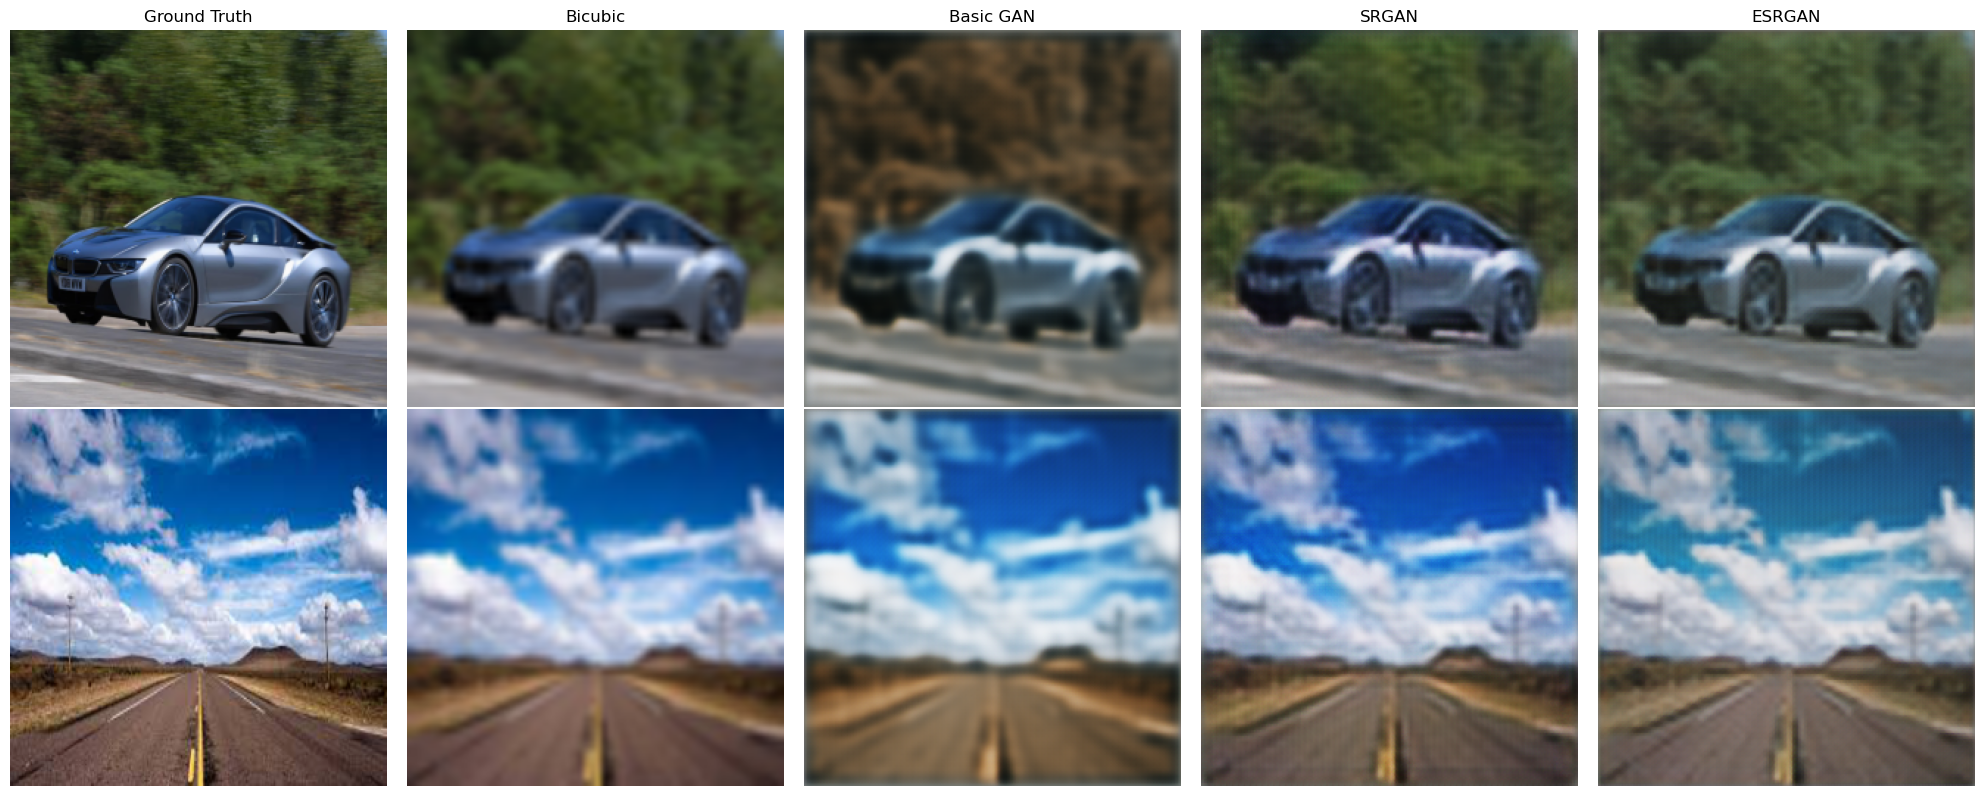

In [99]:
import torch.nn.functional as F

def visualize_sr_results(models, dataloader, device, num_samples=3, scale_factor=4):
    lr_imgs, hr_imgs = next(iter(dataloader))
    num_samples = min(num_samples, lr_imgs.size(0))
    lr_imgs = lr_imgs.to(device)
    hr_imgs = hr_imgs.to(device)

    # FIX: check scale factor consistency
    expected_hr_size = lr_imgs.shape[-1] * scale_factor
    actual_hr_size = hr_imgs.shape[-1]
    assert expected_hr_size == actual_hr_size, \
        f"Scale factor mismatch: LR {lr_imgs.shape[-1]} * {scale_factor} != HR {actual_hr_size}"

    for model in models.values():
        model.to(device)
        model.eval()

    fig, axes = plt.subplots(num_samples, len(models) + 2, figsize=(4*(len(models)+2), 4*num_samples))
    if num_samples == 1:
        axes = [axes]

    for i in range(num_samples):
        # Ground Truth
        hr = hr_imgs[i].cpu() * 0.5 + 0.5
        hr = torch.clamp(hr, 0, 1)
        axes[i][0].imshow(transforms.ToPILImage()(hr))
        axes[i][0].set_title('Ground Truth' if i == 0 else '')
        axes[i][0].axis('off')

        # Bicubic
        lr = lr_imgs[i:i+1]
        bicubic = F.interpolate(lr, scale_factor=scale_factor, mode='bicubic', align_corners=False)[0].cpu() * 0.5 + 0.5
        bicubic = torch.clamp(bicubic, 0, 1)
        axes[i][1].imshow(transforms.ToPILImage()(bicubic))
        axes[i][1].set_title('Bicubic' if i == 0 else '')
        axes[i][1].axis('off')

        # Model outputs
        for j, (name, model) in enumerate(models.items()):
            with torch.no_grad():
                sr = model(lr)
            sr = sr[0].cpu() * 0.5 + 0.5
            sr = torch.clamp(sr, 0, 1)
            axes[i][j+2].imshow(transforms.ToPILImage()(sr))
            axes[i][j+2].set_title(name if i == 0 else '')
            axes[i][j+2].axis('off')
    plt.tight_layout()
    plt.show()

# FIX: only call if models have been trained
if 'basic_gen' in dir() and 'srgan_gen' in dir() and 'esrgan_gen' in dir():
    models_dict = {
        'Basic GAN': basic_gen,
        'SRGAN': srgan_gen,
        'ESRGAN': esrgan_gen
    }
    print("Generating super-resolution comparison...")
    visualize_sr_results(models_dict, sr_loader, device, num_samples=3)

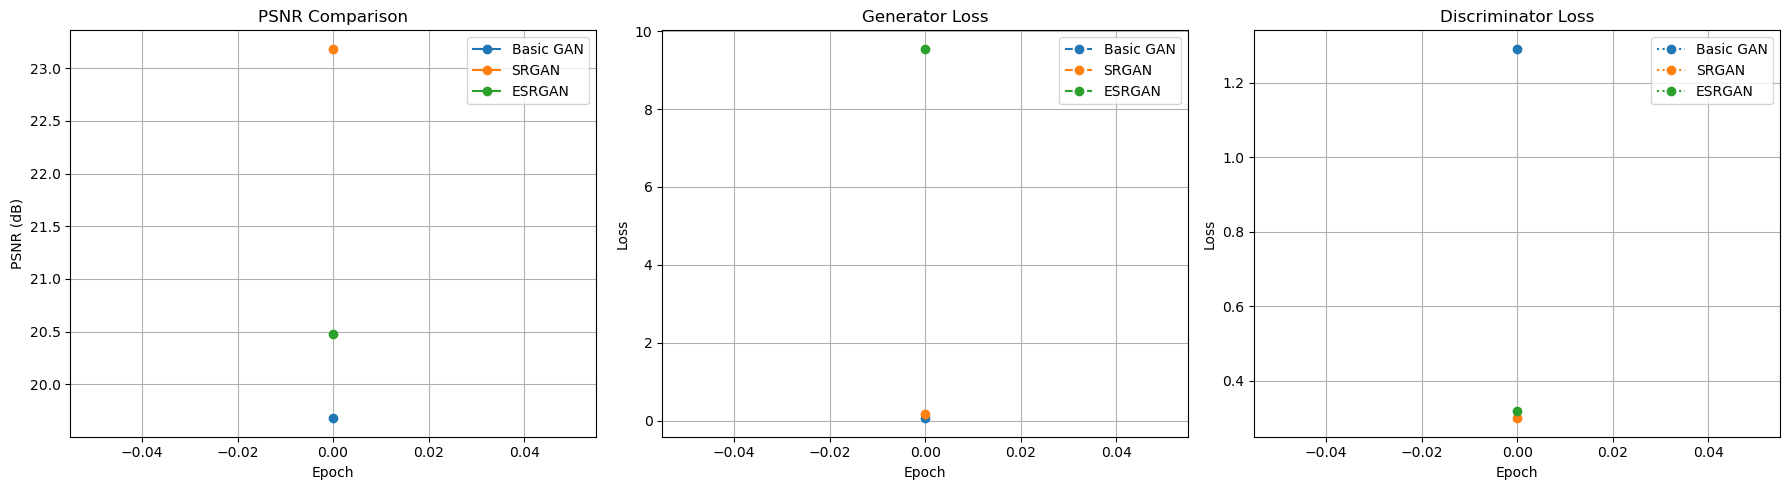

In [101]:
def plot_training_curves(histories_dict):
    """histories_dict: {'name': history_dict, ...}"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for name, hist in histories_dict.items():
        if 'psnr' in hist:
            axes[0].plot(hist['psnr'], label=name, marker='o')
        if 'g_loss' in hist:
            axes[1].plot(hist['g_loss'], label=name, linestyle='--', marker='o')
        if 'd_loss' in hist:
            axes[2].plot(hist['d_loss'], label=name, linestyle=':', marker='o')
    axes[0].set_title('PSNR Comparison')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('PSNR (dB)')
    axes[0].legend()
    axes[0].grid(True)
    axes[1].set_title('Generator Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)
    axes[2].set_title('Discriminator Loss')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Loss')
    axes[2].legend()
    axes[2].grid(True)
    plt.tight_layout()
    plt.show()

# FIX: only plot if histories exist
histories = {}
if 'basic_history' in dir():
    histories['Basic GAN'] = basic_history
if 'srgan_history' in dir():
    histories['SRGAN'] = srgan_history
if 'esrgan_history' in dir():
    histories['ESRGAN'] = esrgan_history
if histories:
    plot_training_curves(histories)
else:
    print("No training histories found. Train at least one model first.")